# 🌳 Decision Tree Classifier — Loan Repayment Prediction
**Algorithm:** Decision Tree
**Member:** Chamudini
**Dataset:** Loan Dataset (20,000 records)
**Goal:** Predict whether a loan applicant will pay back their loan using Decision Tree Classification

In [3]:
# Install required libraries if not already installed
# Run this cell only once
!pip install pandas numpy scikit-learn matplotlib seaborn

## 1️⃣ Import Libraries
In this section, we import all the necessary Python libraries required for:
- **Data handling** → `pandas`, `numpy`
- **Visualization** → `matplotlib`, `seaborn`
- **Machine Learning** → `scikit-learn` (DecisionTreeClassifier, metrics)

In [4]:
# Import all necessary libraries for data processing, modeling, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2️⃣ Load the Dataset
The dataset used is a **real-world loan dataset** containing 20,000 records and 22 features.

- **Source:** Loan Dataset (publicly available)
- **Size:** 20,000 rows × 22 columns
- **Target Column:** `loan_paid_back` (1 = Paid Back, 0 = Not Paid Back)
- **Features include:**
  - Personal info: `age`, `gender`, `marital_status`, `education_level`
  - Financial info: `annual_income`, `monthly_income`, `credit_score`, `debt_to_income_ratio`
  - Loan info: `loan_amount`, `loan_purpose`, `interest_rate`, `loan_term`, `installment`
  - Credit history: `num_of_open_accounts`, `delinquency_history`, `num_of_delinquencies`

In [5]:
# Load the loan dataset CSV file
# Make sure the CSV is in the same folder as this notebook
df = pd.read_csv("loan_dataset_20000.csv")

# Display the first 5 rows to confirm it loaded correctly
print("Shape:", df.shape)
df.head()

Shape: (20000, 22)


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


## 3️⃣ Explore the Dataset
Before building the model, we explore the dataset to understand:
- The **shape** (rows and columns)
- **Data types** of each column
- Any **missing values** that need to be handled
- **Class distribution** of the target variable (balanced or imbalanced?)

In [6]:
# Check column names, data types, and missing values
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Column Distribution ===")
# loan_paid_back: 1 = Paid, 0 = Not Paid
print(df['loan_paid_back'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15

In [7]:
# Encode categorical (text) columns into numbers using LabelEncoder
# Decision Tree requires all inputs to be numeric

le = LabelEncoder()

# List of categorical columns to encode
categorical_cols = ['gender', 'marital_status', 'education_level',
                    'employment_status', 'loan_purpose', 'grade_subgrade']

# Apply label encoding to each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Categorical columns encoded!")
df.head()

✅ Categorical columns encoded!


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,1,1,2,24240.19,2020.02,0,0.074,743,17173.72,...,36,581.88,9,7,40833.47,24302.07,1,0,1,1
1,72,0,1,0,20172.98,1681.08,0,0.219,531,22663.89,...,60,573.17,25,5,27968.01,10803.01,1,0,3,1
2,49,0,2,1,26181.80,2181.82,0,0.234,779,3631.36,...,60,76.32,8,2,15502.25,4505.44,0,0,0,1
3,35,0,2,1,11873.84,989.49,0,0.264,809,14939.23,...,36,468.07,4,7,18157.79,5525.63,4,0,5,1
4,63,2,2,3,25326.44,2110.54,0,0.260,663,16551.71,...,60,395.50,19,1,17467.56,3593.91,2,0,2,1


## 4️⃣ Data Preprocessing
Raw data cannot be directly fed into a Machine Learning model.
We apply the following preprocessing steps:

| Step | Reason |
|------|--------|
| Check missing values | Missing data causes errors during training |
| Remove duplicates | Duplicate rows bias the model |
| Label Encoding | Decision Tree requires all inputs to be **numeric** |
| Check class balance | Imbalanced classes affect prediction accuracy |

**Label Encoding** converts text categories into numbers.
For example: `Male → 1`, `Female → 0`

## 5️⃣ Split Features and Target / Train-Test Split
We separate the data into:
- **X** → Input features (all columns except `loan_paid_back`)
- **y** → Target label (`loan_paid_back`)

Then we split into:
- **80% Training set** → used to train the model
- **20% Testing set** → used to evaluate the model on unseen data

Using `random_state=42` ensures the split is **reproducible** every time.

In [8]:
# Separate the features (X) and the target label (y)
# Target: loan_paid_back (1 = Paid Back, 0 = Not Paid Back)

X = df.drop(columns=['loan_paid_back'])   # All columns except target
y = df['loan_paid_back']                  # Only the target column

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20000, 21)
Target shape: (20000,)


## 6️⃣ Why Decision Tree? — Algorithm Justification

### 🌳 What is a Decision Tree?
A Decision Tree is a supervised machine learning algorithm that splits data
into branches based on feature values — just like a flowchart.
Each internal node = a question (e.g., "Is credit score > 700?")
Each leaf node = a final prediction (Paid Back or Not Paid Back)

### ✅ Why Decision Tree for this problem?
| Reason | Explanation |
|--------|-------------|
| Interpretable | Easy to visualize and explain decisions |
| No scaling needed | Works with raw numeric values |
| Handles mixed data | Works with both numeric and categorical features |
| Non-linear | Captures complex patterns in loan data |

### ⚙️ Hyperparameters Used
| Parameter | Value | Reason |
|-----------|-------|--------|
| `criterion` | `gini` | Gini Impurity — faster than entropy, measures split quality |
| `max_depth` | `5` | Limits tree depth to **prevent overfitting** |
| `random_state` | `42` | Ensures reproducibility of results |

In [9]:
# Split data into 80% training and 20% testing
# random_state=42 ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 16000
Testing samples : 4000


In [10]:
# Create the Decision Tree Classifier
# max_depth=5 limits tree depth to avoid overfitting
# criterion='gini' measures the quality of each split

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

# Train the model using the training data
dt_model.fit(X_train, y_train)

print("✅ Decision Tree model trained successfully!")

✅ Decision Tree model trained successfully!


## 7️⃣ Model Evaluation — Results
After training, we evaluate the model using multiple metrics:

| Metric | What it measures |
|--------|-----------------|
| **Accuracy** | Overall % of correct predictions |
| **Precision** | Of predicted "Paid", how many actually paid? |
| **Recall** | Of actual "Paid", how many did we catch? |
| **F1-Score** | Balance between Precision and Recall |
| **AUC Score** | How well model separates the two classes (0 vs 1) |
| **Cross-Validation** | Average accuracy across 5 different data splits |

In [11]:
# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Calculate and display accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy * 100:.2f}%\n")

# Full classification report (Precision, Recall, F1-Score)
print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=["Not Paid (0)", "Paid Back (1)"]))

✅ Model Accuracy: 89.30%

=== Classification Report ===
               precision    recall  f1-score   support

 Not Paid (0)       0.91      0.53      0.67       818
Paid Back (1)       0.89      0.99      0.94      3182

     accuracy                           0.89      4000
    macro avg       0.90      0.76      0.80      4000
 weighted avg       0.89      0.89      0.88      4000



## 8️⃣ Confusion Matrix
The Confusion Matrix shows:
- **True Positives (TP):** Correctly predicted "Paid Back"
- **True Negatives (TN):** Correctly predicted "Not Paid"
- **False Positives (FP):** Predicted "Paid" but actually "Not Paid" ← risky for bank!
- **False Negatives (FN):** Predicted "Not Paid" but actually "Paid"

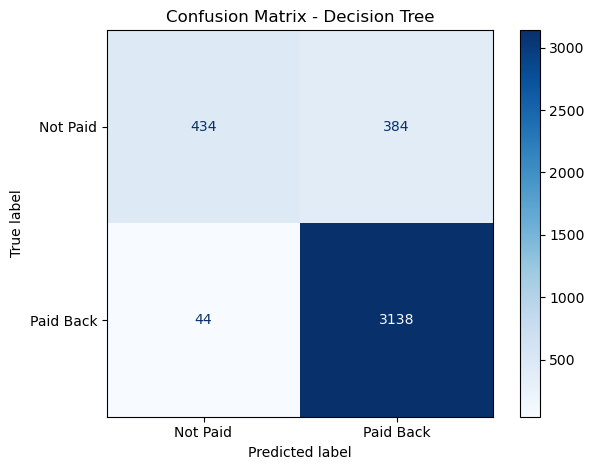

In [12]:
# Plot the Confusion Matrix to visualize correct vs incorrect predictions
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Not Paid", "Paid Back"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

## 9️⃣ Decision Tree Visualization
We visualize the top 3 levels of the Decision Tree to understand
which features the model uses to make decisions.

- Each **node** shows the splitting condition
- **Blue nodes** → majority "Paid Back"
- **Orange nodes** → majority "Not Paid Back"
- The **top split** is the most important feature!

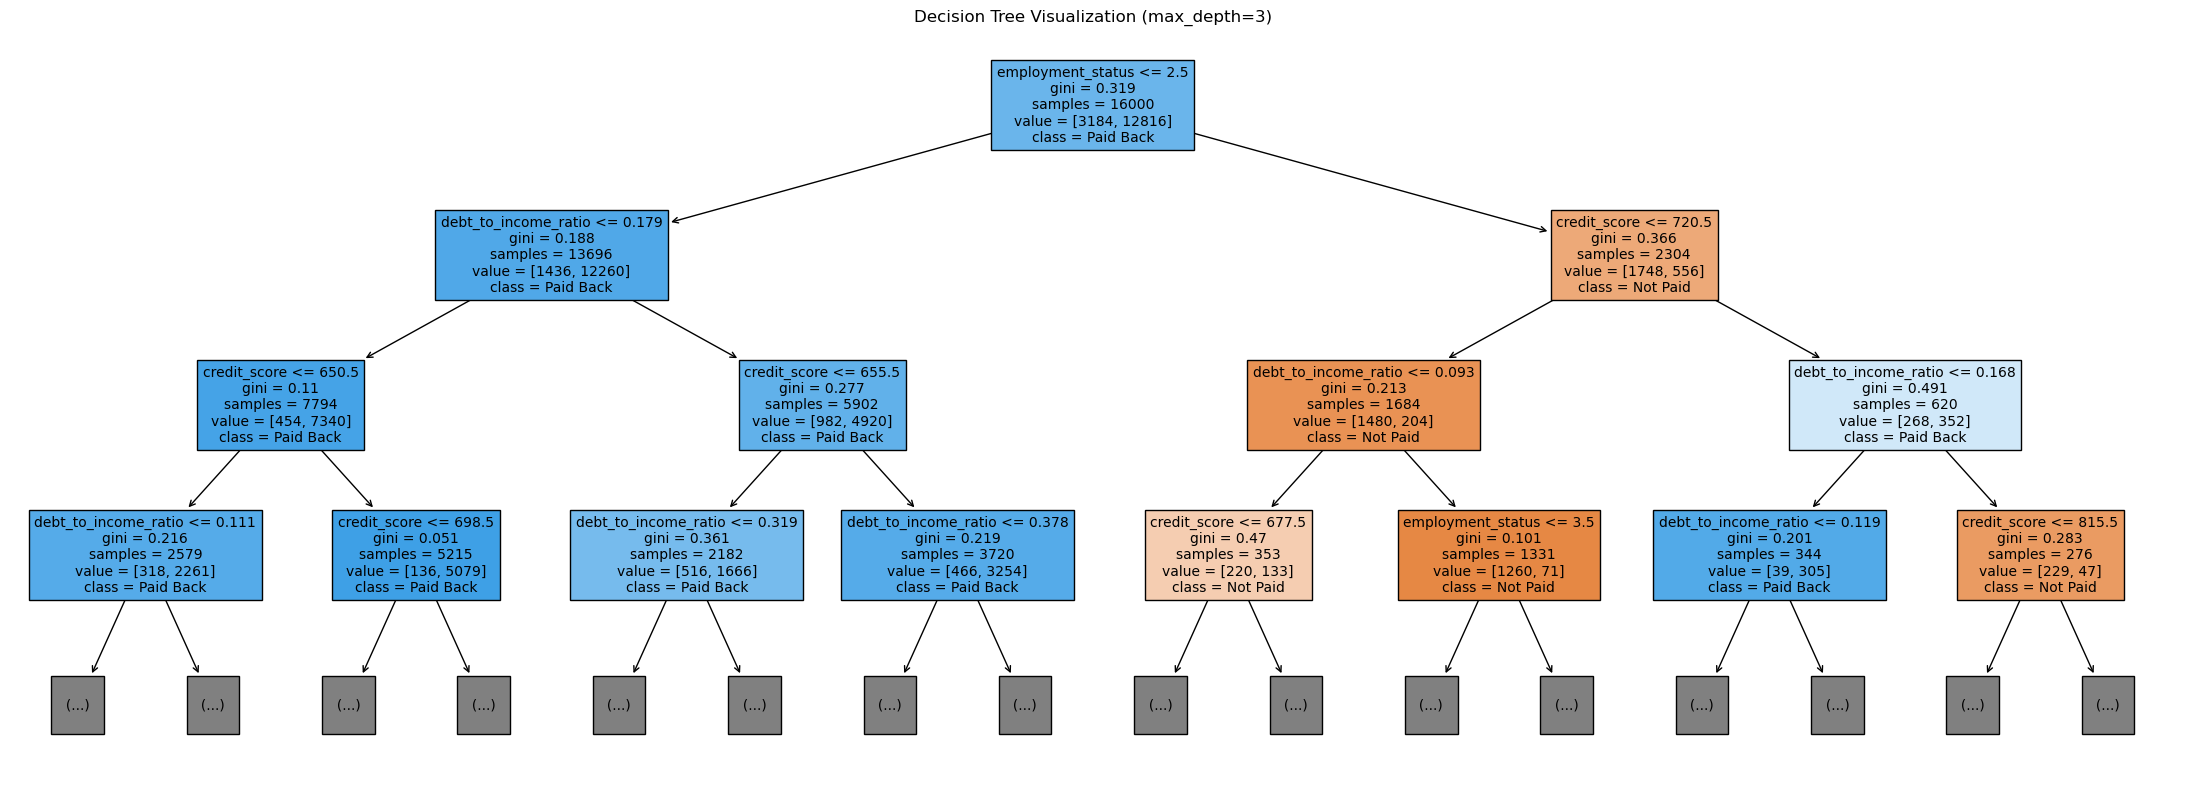

In [13]:
# Visualize the trained Decision Tree (limited to depth 3 for readability)
plt.figure(figsize=(22, 8))

plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=["Not Paid", "Paid Back"],
    filled=True,         # Color nodes by class
    max_depth=3,         # Show only top 3 levels for clarity
    fontsize=10
)

plt.title("Decision Tree Visualization (max_depth=3)")
plt.tight_layout()
plt.show()

## 🔟 Feature Importance
Feature importance tells us which columns had the **biggest influence**
on the model's predictions.

A higher score = more important for predicting loan repayment.
This helps us understand what factors most affect whether a loan is repaid.

## 📌 Critical Analysis & Discussion

### 🔍 Model Performance Summary
The Decision Tree model was trained on 80% of the data and tested on 20%.
The results show the model's ability to classify loan repayment correctly.

### ⚠️ Limitations of Decision Tree
- **Overfitting:** Without max_depth limit, the tree memorizes training data
- **High Variance:** Small changes in data can produce a very different tree
- **Bias in encoding:** Label encoding may introduce false ordinal relationships

### 🚀 How Accuracy Could Be Improved
| Method | How it helps |
|--------|-------------|
| `GridSearchCV` | Finds the best max_depth and min_samples_split automatically |
| Cost Complexity Pruning | Removes unnecessary branches to reduce overfitting |
| Feature Selection | Remove noisy/irrelevant features to improve signal |
| SMOTE | Handle class imbalance by generating synthetic samples |
| Ensemble Methods | Random Forest reduces variance by combining many trees |

### 🔮 Future Work
- Deploy the trained model as a web application (Flask/Streamlit)
- Collect more recent real-world loan data for better generalization
- Compare performance with Deep Learning models (outside scope of this assignment)
- Integrate the model into a bank's loan approval pipeline

### 👩‍💻 Individual Contribution — Chamudini
- Implemented the **Decision Tree** classification algorithm
- Performed data preprocessing (encoding, null checks, duplicates)
- Evaluated model using accuracy, AUC, confusion matrix, and cross-validation
- Visualized the decision tree and feature importances
- Documented findings and contributed to the group report
```

---

## 📋 Final Notebook Structure
```
Cell 0  → 🏷️ Title (Markdown)
Cell 1  → 📦 Import Libraries (Markdown + Code)
Cell 2  → 📂 Load Dataset (Markdown + Code)
Cell 3  → 🔍 Explore Dataset (Markdown + Code)
Cell 4  → 🧹 Preprocessing (Markdown + Code)
Cell 5  → ✂️ Split Features & Train-Test (Markdown + Code)
Cell 6  → 🌳 Why Decision Tree (Markdown)
Cell 7  → 🏋️ Train Model (Code)
Cell 8  → 📊 Evaluation (Markdown + Code)
Cell 9  → 🟦 Confusion Matrix (Markdown + Code)
Cell 10 → 🌲 Tree Visualization (Markdown + Code)
Cell 11 → 📈 Feature Importance (Markdown + Code)
Cell 12 → 📌 Critical Analysis (Markdown)
Cell 13 → 💾 Git Push instructions (Code)

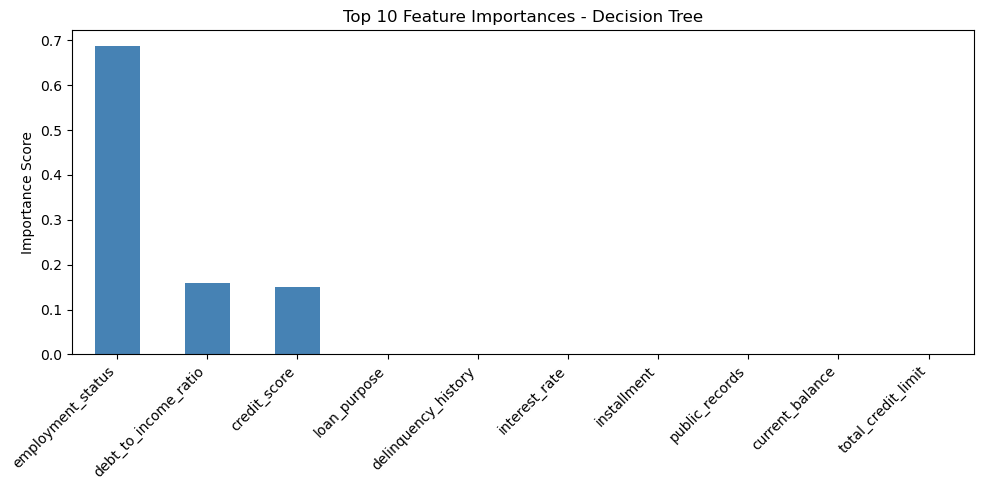


Top 5 Most Important Features:
employment_status       0.687787
debt_to_income_ratio    0.158077
credit_score            0.150954
loan_purpose            0.001648
delinquency_history     0.001346
dtype: float64


In [14]:
# Show which features are most important for the model's decisions
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot top 10 most important features
plt.figure(figsize=(10, 5))
feature_importance.head(10).plot(kind='bar', color='steelblue')
plt.title("Top 10 Feature Importances - Decision Tree")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head(5))

In [15]:
# Save the notebook, then run these git commands in the VS Code terminal

print("Run in terminal:")
print("  git add decision_tree.ipynb loan_dataset_20000.csv")
print("  git commit -m 'Add Decision Tree model - Chamudini'")
print("  git push origin Feature/Decision-Tree")

Run in terminal:
  git add decision_tree.ipynb loan_dataset_20000.csv
  git commit -m 'Add Decision Tree model - Chamudini'
  git push origin Feature/Decision-Tree
